# Προσέγγιση 1: Ταξινόμηση με Raw Windowed Data

Αυτό το notebook υλοποιεί την **πρώτη προσέγγιση** του project: τα αρχικά δεδομένα τμηματοποιούνται με sliding window, ισοπεδώνονται (flatten) και τροφοδοτούνται απευθείας στους ταξινομητές χωρίς feature engineering.

Τα βήματα που ακολουθούμε:
1. Φόρτωση δεδομένων από MongoDB
2. Εξερεύνηση & οπτικοποίηση raw vs. processed σήματος
3. Preprocessing (Z-score cleaning + Butterworth filter)
4. Sliding window segmentation + flatten
5. Session-based train/test split
6. Εκπαίδευση & αξιολόγηση RandomForest, SVM, KNN
7. Βελτιστοποίηση με Grid Search


## Imports & Σύνδεση στη MongoDB

Φορτώνουμε όλες τις απαραίτητες βιβλιοθήκες και συνδεόμαστε στη MongoDB χρησιμοποιώντας τις παραμέτρους του `config.yml`.

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from utils import apply_filter, sliding_window_pd, flatten_instances_df
from utils_visual import plot_instance_time_domain

config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]

## Εξερεύνηση Dataset

Πριν αρχίσουμε οποιαδήποτε επεξεργασία, ελέγχουμε πόσες εγγραφές έχουμε ανά κίνηση και χρήστη, και πόση συνολική χρονική διάρκεια κατέχει κάθε κλάση. Αυτό μας βοηθά να εντοπίσουμε τυχόν ανισορροπίες στο dataset.

          gesture_id user  total_recordings  total_duration_sec
0  scroll-down-index   01                 5              270.50
1  scroll-down-index   02                 5              326.79
2    scroll-up-index   01                 5              356.33
3    scroll-up-index   02                 5              379.47
4   swipe-left-index   01                 5              347.11
5   swipe-left-index   02                 5              346.65
6  swipe-right-index   01                 5              344.40
7  swipe-right-index   02                 5              353.36
8     texting-single   01                 5              372.57
9     texting-single   02                 5              326.80


C:\Users\ssiou\AppData\Local\Temp\ipykernel_22096\3669479016.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=duration_per_class, x="gesture", y="total_duration_sec", palette="viridis")


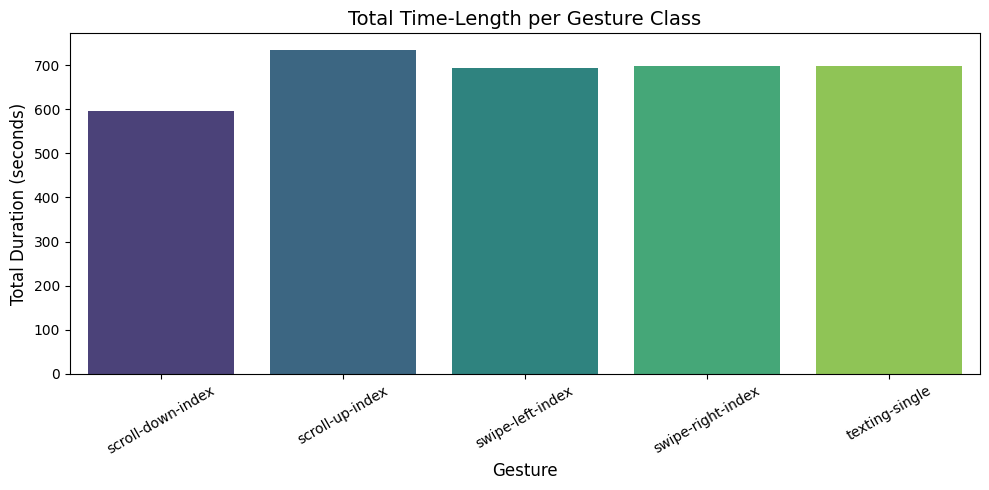

In [3]:
records = []
for doc in coll.find({}):
    df_doc = pd.DataFrame(doc["data"])
    duration_sec = len(df_doc) / 100
    records.append({
        "gesture_id": doc.get("gesture_id"),
        "user": doc.get("user"),
        "n_samples": len(df_doc),
        "duration_sec": duration_sec
    })

df_summary = pd.DataFrame(records)
print(df_summary.groupby(["gesture_id", "user"]).agg(
    total_recordings=("n_samples", "count"),
    total_duration_sec=("duration_sec", "sum")
).reset_index())

duration_per_class = df_summary.groupby("gesture_id")["duration_sec"].sum().reset_index()
duration_per_class.columns = ["gesture", "total_duration_sec"]

plt.figure(figsize=(10, 5))
sns.barplot(data=duration_per_class, x="gesture", y="total_duration_sec", palette="viridis")
plt.title("Total Time-Length per Gesture Class", fontsize=14)
plt.xlabel("Gesture", fontsize=12)
plt.ylabel("Total Duration (seconds)", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("duration_per_class.png", dpi=150)
plt.show()

## Ορισμός Συνάρτησης Preprocessing

Η `process_sensor_data` κάνει τρία πράγματα:

- **Trim:** Αφαιρεί τα τελευταία `trim_size` δείγματα κάθε εγγραφής. Αυτά συνήθως περιέχουν θόρυβο από τη στιγμή που σταματάμε την κίνηση.
- **Z-score outlier removal:** Για κάθε άξονα, υπολογίζει το Z-score κάθε δείγματος. Όσα ξεπερνούν threshold=3 σηματοδοτούνται ως outliers και γίνονται `NaN`.
- **Interpolation:** Τα `NaN` αντικαθίστανται με linear interpolation μεταξύ των γειτονικών τιμών. Για τυχόν `NaN` στην αρχή/τέλος χρησιμοποιείται forward/backward fill.

In [10]:
def process_sensor_data(df, trim_size=100, z_threshold=3):
    
    if trim_size > 0:
        df_processed = df.iloc[:-trim_size].copy()
    else:
        df_processed = df.copy()
    
    for col_name in df_processed.columns:
        mean_val = df_processed[col_name].mean()
        std_val = df_processed[col_name].std()
        
        
        if std_val == 0 or np.isnan(std_val):
            continue
        
        z_scores = (df_processed[col_name] - mean_val) / std_val
        
       
        df_processed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        
        df_processed[col_name] = df_processed[col_name].interpolate(method="linear")
        df_processed[col_name] = df_processed[col_name].ffill().bfill()
    
    return df_processed


gestures = sorted(coll.distinct("gesture_id"))
users = ["01", "02"]

order = config["filter"]["order"]
wn = config["filter"]["wn"]

raw_data_dict = {}
processed_data_dict = {}

## Οπτικοποίηση Raw Δεδομένων

Εμφανίζουμε boxplots για τους πρώτους 1000 δείγματα κάθε συνδυασμού (κίνηση, χρήστης) στα **ακατέργαστα δεδομένα**. Στόχος είναι να δούμε την κατανομή τιμών και να εντοπίσουμε πιθανά outliers ή διαφορές μεταξύ χρηστών.

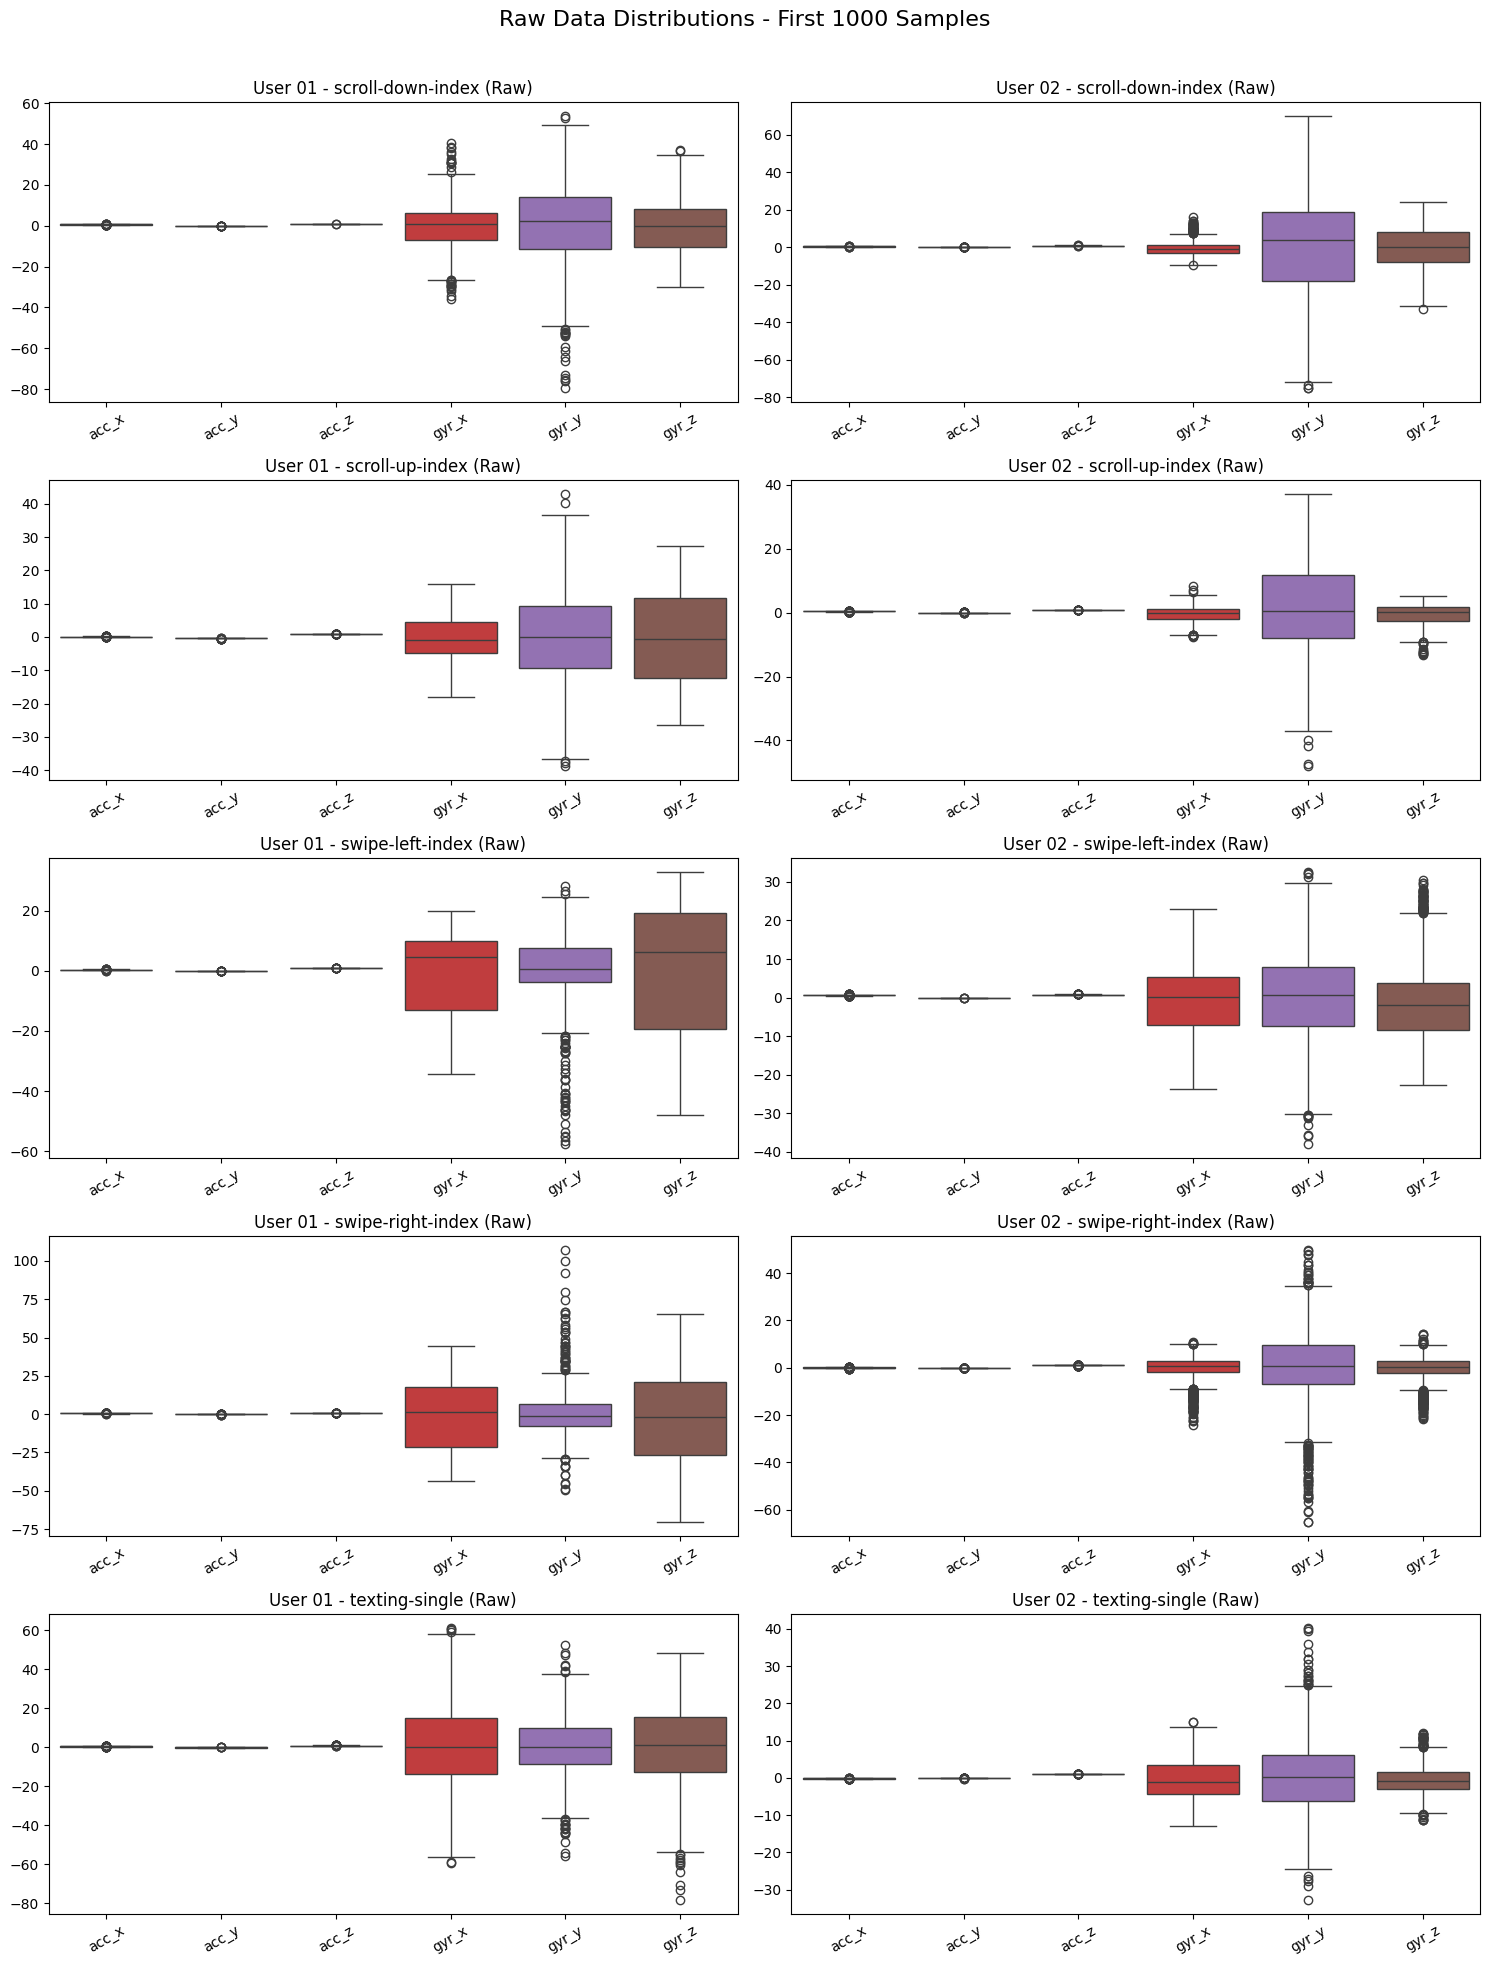

In [11]:
fig_raw, axes_raw = plt.subplots(
    len(gestures), 
    len(users), 
    figsize=(15, 4 * len(gestures))
)

fig_raw.suptitle("Raw Data Distributions - First 1000 Samples", fontsize=16)

axes_raw = np.array(axes_raw).reshape(len(gestures), len(users))

for i, gesture in enumerate(gestures):
    for j, user in enumerate(users):
        doc = coll.find_one({
            "gesture_id": gesture,
            "user": user
        })
        
        if doc is not None:
            df_raw = pd.DataFrame(doc["data"])
            
            
            sensor_cols = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
            df_raw = df_raw[sensor_cols]
            
            
            df_raw_plot = df_raw.iloc[:1000].copy()
            
           
            raw_data_dict[(gesture, user)] = df_raw
            
            sns.boxplot(data=df_raw_plot, ax=axes_raw[i, j])
            axes_raw[i, j].set_title(f"User {user} - {gesture} (Raw)")
            axes_raw[i, j].tick_params(axis="x", rotation=30)
        else:
            axes_raw[i, j].set_title(f"User {user} - {gesture} (No data)")
            axes_raw[i, j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Οπτικοποίηση Μετά το Preprocessing

Εφαρμόζουμε cleaning + Butterworth low-pass filter και ξαναδείχνουμε τα boxplots. Η σύγκριση πριν/μετά μας επιτρέπει να αξιολογήσουμε πόσο αποτελεσματικό είναι το preprocessing μας.

Το Butterworth φίλτρο (4ης τάξης, `Wn=0.1`, low-pass) αφαιρεί υψίσυχνο θόρυβο διατηρώντας τις κύριες κινηματικές πληροφορίες.

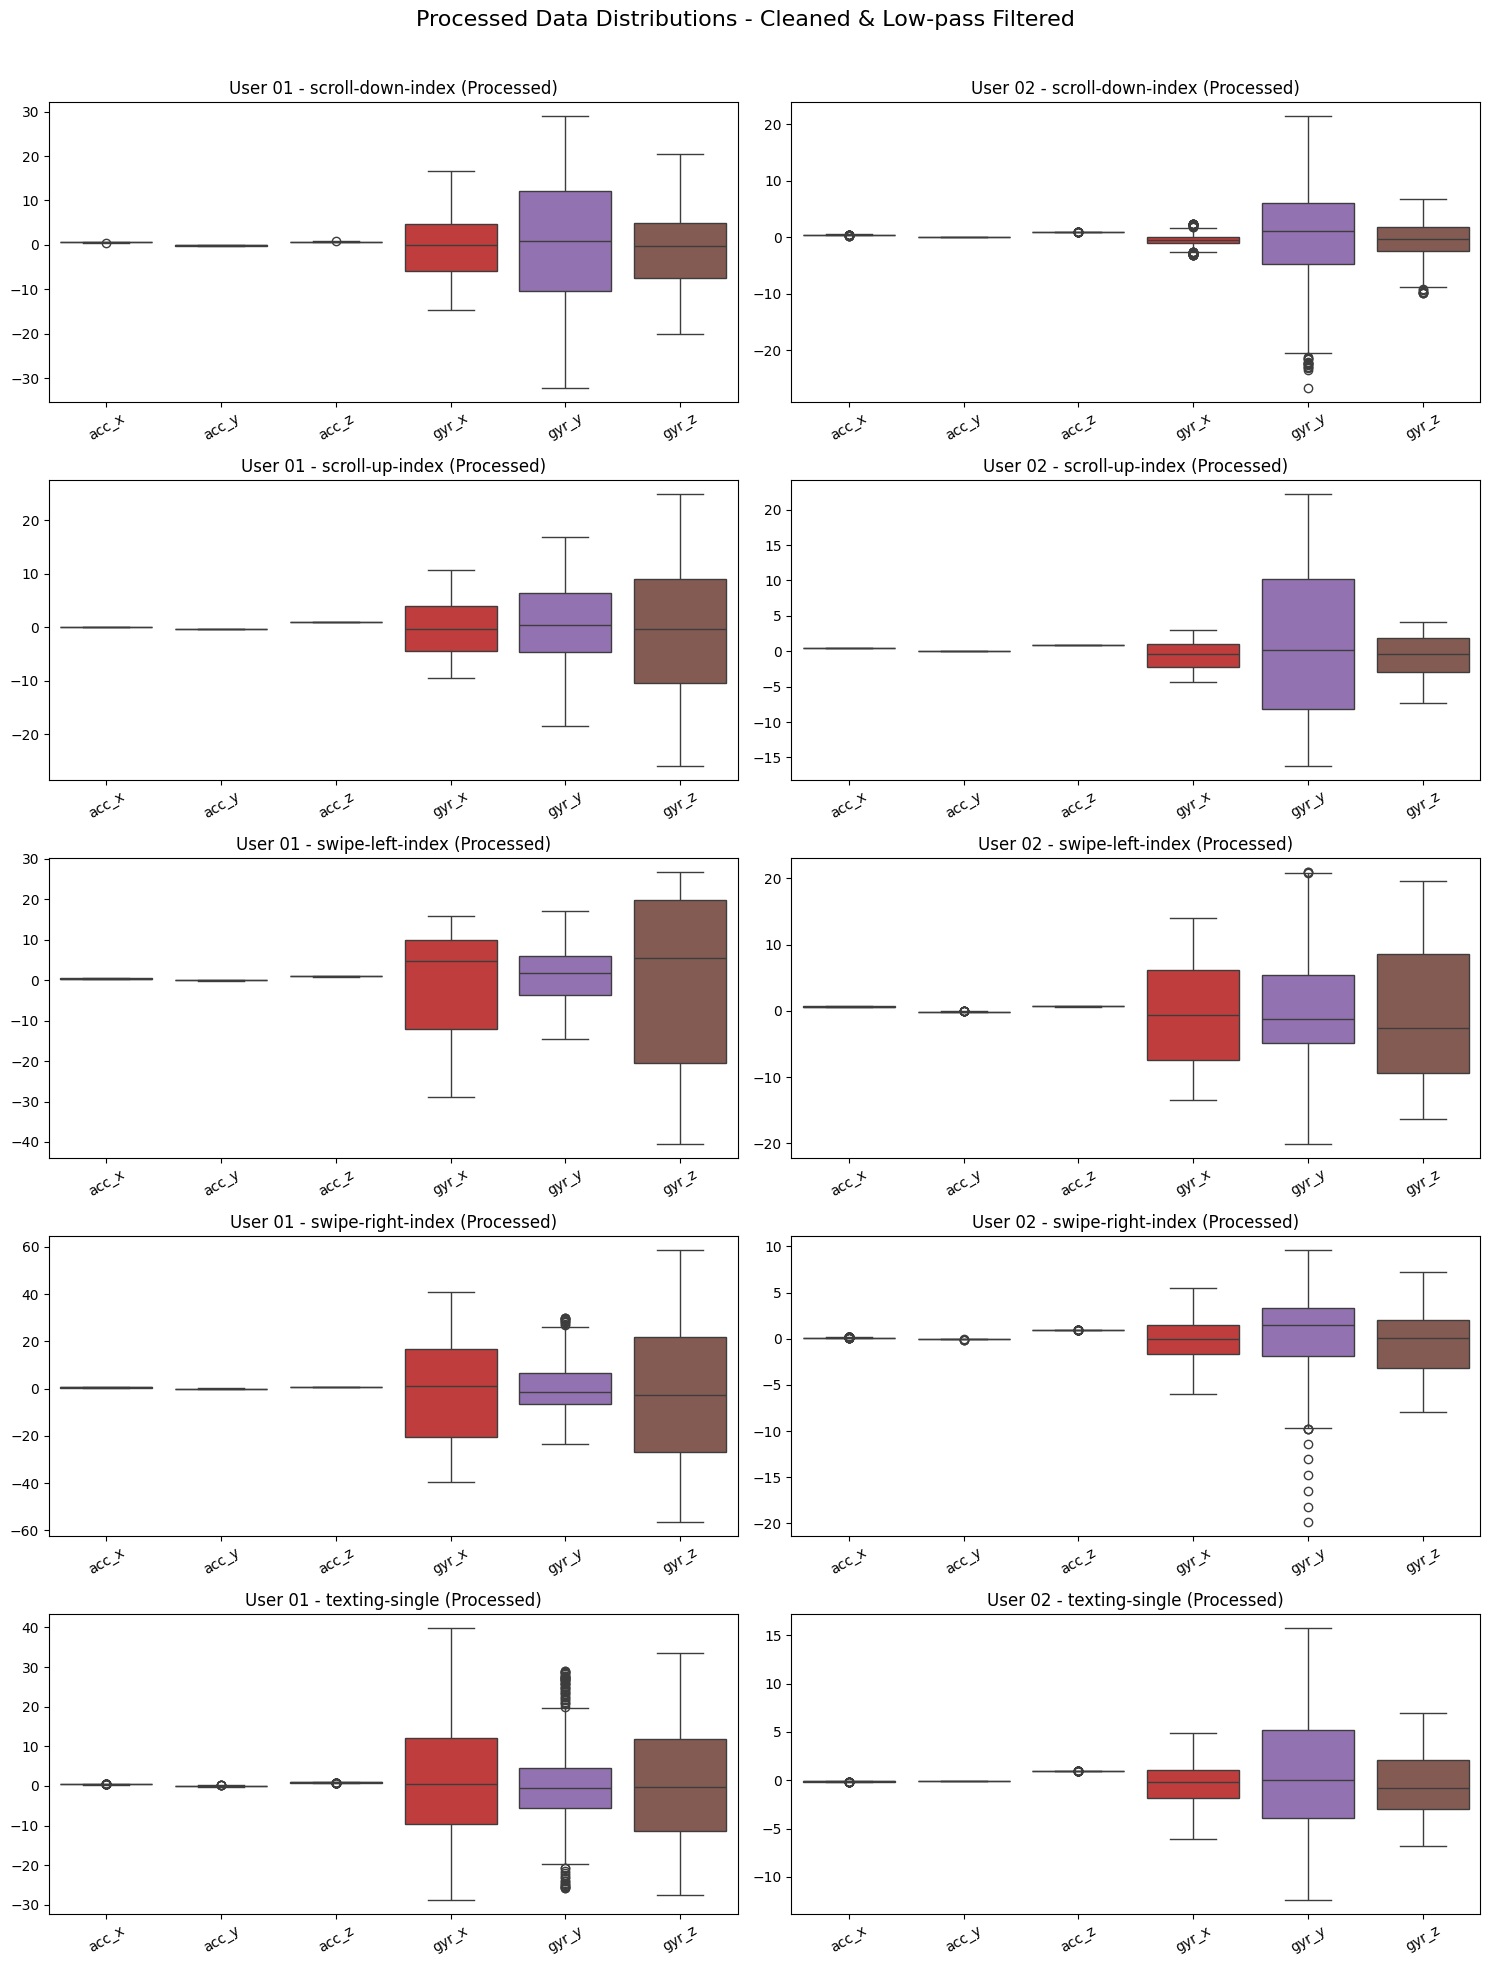

In [12]:
fig_processed, axes_processed = plt.subplots(
    len(gestures), 
    len(users), 
    figsize=(15, 4 * len(gestures))
)

fig_processed.suptitle("Processed Data Distributions - Cleaned & Low-pass Filtered", fontsize=16)

axes_processed = np.array(axes_processed).reshape(len(gestures), len(users))

for i, gesture in enumerate(gestures):
    for j, user in enumerate(users):
        
        if (gesture, user) in raw_data_dict:
            df_raw = raw_data_dict[(gesture, user)]
            
            
            df_clean = process_sensor_data(
                df_raw,
                trim_size=100,
                z_threshold=3
            )
            
            
            df_filtered = df_clean.apply(
                apply_filter,
                args=(order, wn, "lowpass")
            )
            
            processed_data_dict[(gesture, user)] = df_filtered
            
            
            df_filtered_plot = df_filtered.iloc[:1000].copy()
            
            sns.boxplot(data=df_filtered_plot, ax=axes_processed[i, j])
            axes_processed[i, j].set_title(f"User {user} - {gesture} (Processed)")
            axes_processed[i, j].tick_params(axis="x", rotation=30)
        else:
            axes_processed[i, j].set_title(f"User {user} - {gesture} (No data)")
            axes_processed[i, j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Sliding Window Segmentation & Session-Based Split

Εδώ γίνεται το βασικό data engineering:

**Sliding Window:** Για κάθε εγγραφή εφαρμόζουμε τον αλγόριθμο sliding window με παράμετρους από το config (`ws=500`, `overlap=250`, `win_type='hann'`). Κάθε παράθυρο ισοπεδώνεται (flatten) σε ένα διάνυσμα χαρακτηριστικών.

**Session-Based Split:** Χρησιμοποιούμε έναν `session_tracker` dictionary που μετράει πόσες φορές έχουμε δει κάθε συνδυασμό (user, gesture). Η 5η εμφάνιση (current_session == 5) πηγαίνει στο test set, οι υπόλοιπες στο training.

> Αυτή η στρατηγική αποφεύγει το **window leakage**: αφού τα παράθυρα μιας session είναι χρονικά συνεχόμενα και επικαλυπτόμενα, ένα τυχαίο split θα έβαζε παράθυρα από την ίδια χρονική περιοχή και στο train και στο test.

In [6]:
X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

session_tracker = {} 

window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

all_documents = coll.find({})

for doc in all_documents:
    gesture = doc.get("gesture_id")
    user = doc.get("user")
    
    key = f"{user}_{gesture}"
    
    session_tracker[key] = session_tracker.get(key, 0) + 1
    current_session = session_tracker[key]
    
    df = pd.DataFrame(doc["data"])
    df_clean = process_sensor_data(df)
    df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
    
    windows = sliding_window_pd(df_filtered, ws=window_size, overlap=overlap, print_stats=False)
    
    if len(windows) > 0:
        flattened_df = flatten_instances_df(windows)
        window_arrays = flattened_df.to_numpy()
        
        for window_array in window_arrays:
            if current_session == 5:
                X_test_list.append(window_array)
                y_test_list.append(gesture)
            else:
                X_train_list.append(window_array)
                y_train_list.append(gesture)

X_train_raw = np.array(X_train_list)
y_train_raw = np.array(y_train_list)
X_test_raw = np.array(X_test_list)
y_test_raw = np.array(y_test_list)

## Κωδικοποίηση Labels & Κανονικοποίηση

- **LabelEncoder:** Μετατρέπει τα string labels (π.χ. `'scroll-down-index'`) σε αριθμούς (0–4). Κάνουμε `fit` πάνω στο σύνολο train+test για να μην έχουμε unseen labels.
- **StandardScaler:** Κανονικοποιεί κάθε feature σε μέσο 0 και τυπική απόκλιση 1. Ο scaler εκπαιδεύεται **μόνο** στο training set και εφαρμόζεται στο test, ώστε να μην υπάρχει data leakage από τα test statistics.

In [7]:
le = LabelEncoder()
le.fit(np.concatenate((y_train_raw, y_test_raw)))

y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

## Baseline Classifier: Random Forest

Εκπαιδεύουμε ένα Random Forest με default παραμέτρους (100 δέντρα) πάνω στα raw flattened windows. Αξιολογούμε με:
- **Accuracy:** Συνολικό ποσοστό σωστών προβλέψεων
- **Classification Report:** Precision, Recall, F1 ανά κλάση
- **Confusion Matrix:** Για να δούμε ποιες κλάσεις μπερδεύονται μεταξύ τους

Random Forest Accuracy: 0.8245

                   precision    recall  f1-score   support

scroll-down-index       0.82      0.82      0.82       195
  scroll-up-index       0.75      0.42      0.54       196
 swipe-left-index       0.82      0.97      0.89       196
swipe-right-index       0.93      0.96      0.94       226
   texting-single       0.77      0.95      0.85       184

         accuracy                           0.82       997
        macro avg       0.82      0.82      0.81       997
     weighted avg       0.82      0.82      0.81       997



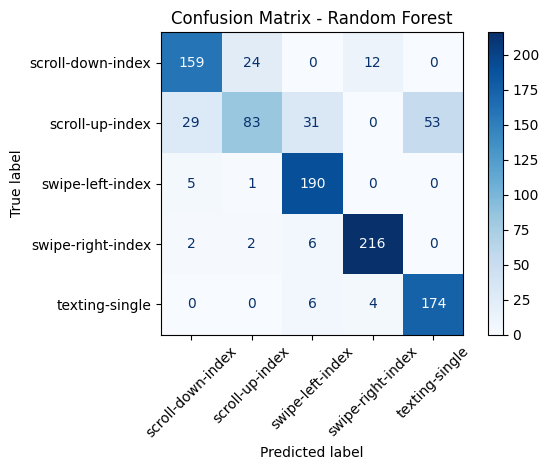

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Baseline Classifier: SVM

Εκπαιδεύουμε SVM με RBF kernel και default παράμετρο `C=1.0`. Το SVM συνήθως αποδίδει καλά σε υψηδιάστατα δεδομένα, οπότε είναι καλός baseline για σύγκριση με το Random Forest.

SVM Baseline Accuracy: 0.7492

                   precision    recall  f1-score   support

scroll-down-index       0.67      0.53      0.59       195
  scroll-up-index       0.60      0.59      0.60       196
 swipe-left-index       0.93      0.88      0.90       196
swipe-right-index       0.95      0.98      0.96       226
   texting-single       0.58      0.73      0.65       184

         accuracy                           0.75       997
        macro avg       0.75      0.74      0.74       997
     weighted avg       0.75      0.75      0.75       997



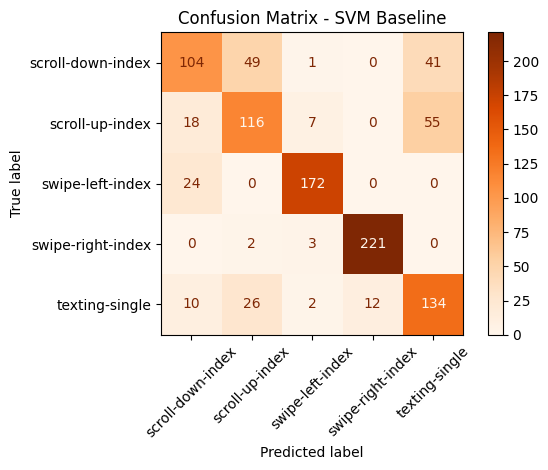

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(f"SVM Baseline Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=le.classes_, cmap='Oranges')
plt.title("Confusion Matrix - SVM Baseline")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Βελτιστοποίηση με Grid Search (3 Classifiers)

Εκτελούμε Grid Search με 3-fold cross-validation για να βρούμε τις καλύτερες υπερπαραμέτρους για RandomForest, SVM και KNN ταυτόχρονα.

Για κάθε classifier:
- Δοκιμάζουμε ένα grid παραμέτρων (π.χ. `n_estimators`, `max_depth` για RF)
- Επιλέγουμε το `best_estimator_` βάσει accuracy στο cross-validation
- Αξιολογούμε το καλύτερο μοντέλο στο held-out test set (Session 5)

> Προσοχή: το CV score είναι συντηρητικό γιατί εκπαιδεύει σε 80% των training sessions. Το τελικό test accuracy αναμένεται υψηλότερο.

--- Training RandomForest ---
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.8285


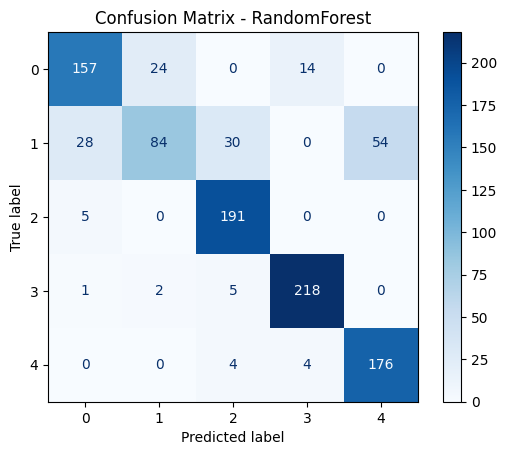



--- Training SVM ---
Best parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.7994


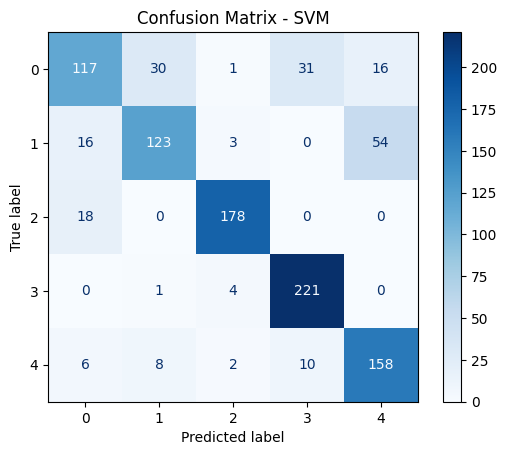



--- Training KNN ---
Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.7974


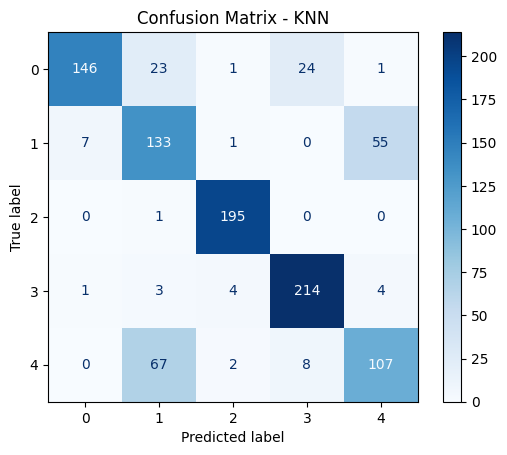

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


models = [
    {
        "name": "RandomForest",
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}
    },
    {
        "name": "SVM",
        "model": SVC(random_state=42),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    },
    {
        "name": "KNN",
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7], "weights": ["uniform", "distance"]}
    }
]


for entry in models:
    print(f"--- Training {entry['name']} ---")
    
    
    grid = GridSearchCV(entry["model"], entry["params"], cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Best parameters: {grid.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {entry['name']}")
    plt.show()
    print("\n")